#  Лабораторные работы
## Классификация с помощью решающих функций

Пять лабораторных работ с наращиванием сложности:
1. Геометрия линейных решающих функций и линейная разделимость.
2. Нахождение линейных решающих функций: градиентный спуск и алгоритм Хо–Кашьяпа.
3. Обобщённые решающие функции и спрямляющие отображения.
4. Метрики, расстояния, клетки Вороного и методы ближайших центров/соседей.
5. Кластеризация (k-means и др.) как основа прототипных методов и связь с линейными методами.

# Лабораторная работа 1
## Линейные решающие функции и линейная разделимость

**Цель:** закрепить понятия решающей функции, областей предпочтения, линейной решающей функции, линейной разделимости и выпуклых оболочек классов.

### Теоретические опорные пункты
- Пространство признаков, множество классов, области предпочтения $X_i$.
- Линейная решающая функция $d(x) = (w, x)$, разделяющая гиперплоскость $S = \{x : d(x)=0\}$.
- Связь линейной разделимости и непересекающихся выпуклых оболочек классов.

### Задание
1. Сгенерировать в 2D три варианта наборов данных: линейно разделимые, слабо пересекающиеся и явно линейно неразделимые классы.
2. Для линейно разделимого случая подобрать вектор весов $w, b$ для ЛРФ и визуализировать разделяющую прямую и области предпочтения.
3. Построить выпуклые оболочки классов и проверить, пересекаются ли они.
4. Для неразделимого случая продемонстрировать, что ни одной линейной гиперплоскостью нельзя корректно разделить классы без ошибок (на уровне эксперимента).
5. Сформулировать выводы о связи выпуклых оболочек и существования линейной разделяющей гиперплоскости.

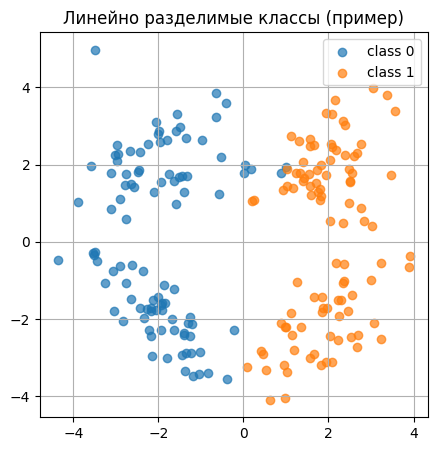

In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.spatial import ConvexHull

np.random.seed(42)

def generate_linear_separable(n_samples=200, class_sep=2.0, random_state=42):
    X, y = datasets.make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, class_sep=class_sep, random_state=random_state)
    return X, y

def generate_overlapping(n_samples=200, class_sep=0.8, noise=0.1, random_state=42):
    X, y = datasets.make_classification(n_samples=n_samples, n_features=2, n_informative=2, n_redundant=0, class_sep=class_sep, random_state=random_state)
    return X, y

def generate_nonlinear_moons(n_samples=200, noise=0.1, random_state=42):
    X, y = datasets.make_moons(
        n_samples=n_samples, 
        random_state= random_state,
        noise=noise
        )
    return X, y

def plot_dataset(X, y, title="Dataset"):
    plt.figure(figsize=(5, 5))
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}", alpha=0.7)
    plt.legend()
    plt.title(title)
    plt.grid(True)
    # plt.show()

# Пример: линейно разделимые классы
X_lin, y_lin = generate_linear_separable()
plot_dataset(X_lin, y_lin, title="Линейно разделимые классы (пример)")

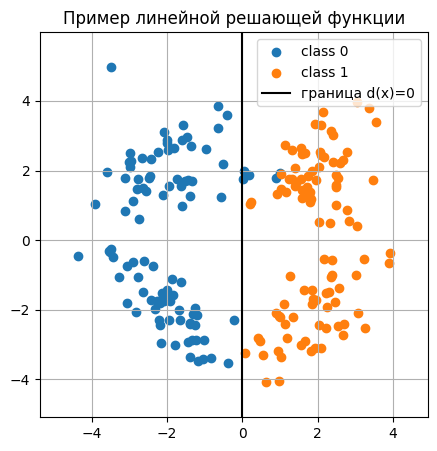

In [2]:
def plot_linear_decision_boundary(X, y, w, b, title="ЛРФ"):
    plt.figure(figsize=(5, 5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xs = np.linspace(x_min, x_max, 200)
    if w[0]**2 + w[1]**2 == 1:
        ys = -(w[0] * xs + b) / w[1]
    else:
        ys = np.zeros_like(xs)
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}")
    plt.plot(xs, ys, 'k-', label="граница d(x)=0")
    plt.xlim((x_min, x_max))
    plt.ylim((y_min, y_max))
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

w_example = np.array([np.sin(np.pi/2), np.cos(np.pi/2)])
b_example = 0.0
plot_linear_decision_boundary(X_lin, y_lin, w_example, b_example,
                             title="Пример линейной решающей функции")

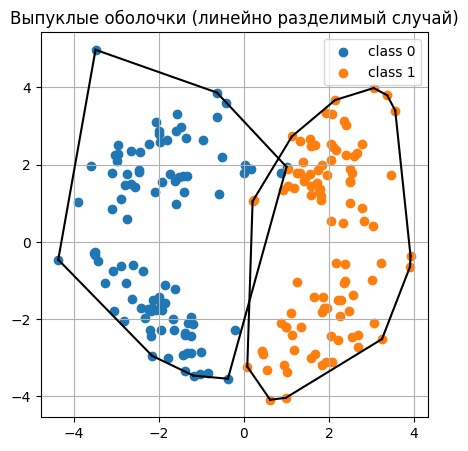

In [3]:
def plot_convex_hulls(X, y, title="Выпуклые оболочки"):
    plt.figure(figsize=(5, 5))
    for cls in np.unique(y):
        Xc = X[y == cls]
        plt.scatter(Xc[:, 0], Xc[:, 1], label=f"class {cls}")
        if len(Xc) >= 3:
            hull = ConvexHull(Xc)
            for simplex in hull.simplices:
                plt.plot(Xc[simplex, 0], Xc[simplex, 1], 'k-')
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

plot_convex_hulls(X_lin, y_lin, title="Выпуклые оболочки (линейно разделимый случай)")

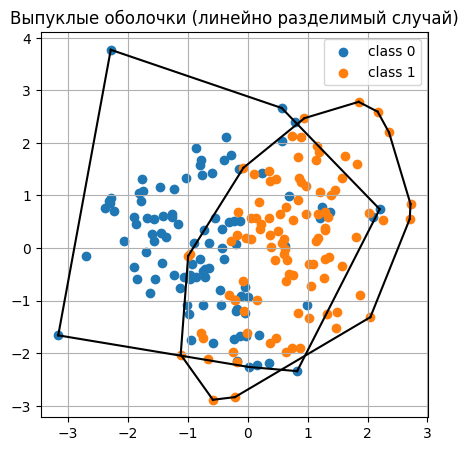

In [4]:

X_unlin, y_unlin = generate_overlapping()

plot_convex_hulls(X_unlin, y_unlin, title="Выпуклые оболочки (линейно разделимый случай)")

# Лабораторная работа 2
## Нахождение ЛРФ: градиентный спуск и алгоритм Хо–Кашьяпа

**Цель:** реализовать два подхода к поиску линейной решающей функции на двухклассовой выборке и сравнить их поведение.

### Теоретические опорные пункты
- Унифицированные векторы $x'_i$ и условие $(w, x'_i) > 0$ для всех $i$.
- Функция критерия $F(w)$ и метод градиентного спуска.
- Переопределённая задача и идея алгоритма Хо–Кашьяпа.

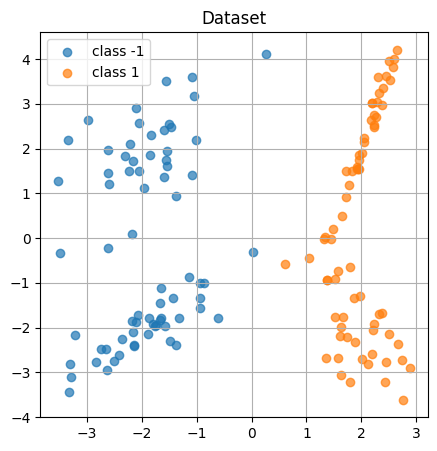

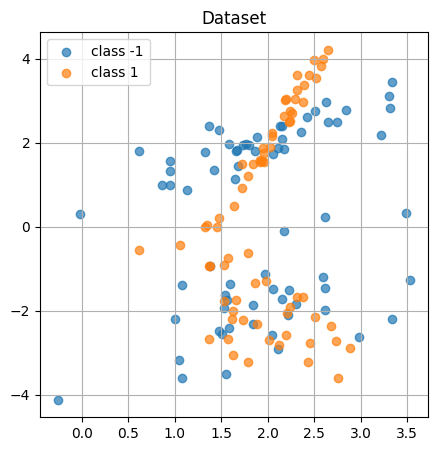

[[-2.61686816  1.97886773  1.        ]
 [ 2.28676539  3.03138591  1.        ]
 [-1.96396676  1.1235469   1.        ]
 [ 2.23891237 -1.92008868  1.        ]
 [ 2.73621152 -2.73072558  1.        ]
 [-2.14866062 -2.4062398   1.        ]
 [-1.00559177  2.20324101  1.        ]
 [ 1.52311497 -1.7716152   1.        ]
 [-1.13286682 -0.87481038  1.        ]
 [ 1.96337722  1.7460957   1.        ]
 [ 2.37338041  2.96608145  1.        ]
 [ 1.62421156 -1.99931927  1.        ]
 [-1.67334692 -1.44624552  1.        ]
 [-2.30573159  1.84078238  1.        ]
 [-3.3126245  -2.81631471  1.        ]
 [-2.64679047 -2.47882824  1.        ]
 [ 1.4557494  -0.01517253  1.        ]
 [-2.83659331 -2.7717513   1.        ]
 [-1.55424136  3.5203651   1.        ]
 [ 1.96033406  1.53562822  1.        ]
 [ 2.5753165   3.82804219  1.        ]
 [-1.47547136  2.4856921   1.        ]
 [ 2.3777178  -1.6812802   1.        ]
 [ 2.39128097  3.36426312  1.        ]
 [ 2.4971654   3.96791206  1.        ]
 [-1.47754619 -2.30223846

In [5]:
def generate_2class_linear(n_samples=200, class_sep=2.0, random_state=0):
    X, y = generate_linear_separable(n_samples=n_samples, class_sep=class_sep, random_state=random_state)
    X = np.concatenate((X, np.ones((X.shape[0], 1))), axis = 1)
    y_signed = np.where(y == 0, -1, 1)
    return X, y_signed

X2, y2 = generate_2class_linear(random_state=0)

# X2_train = np.array([[0,0, 1], [-1,1, 1], [1,0, 1],
#                      [4,2, 1], [3,2, 1 ], [5,3, 1]])
# y2_train = np.array([-1,-1,-1, 1, 1, 1])

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.3, random_state=0)

def make_unified_vectors(X, y):
    """Преобразует выборку в унифицированные векторы: x_i' = y_i * x_i."""
    return X * y[:, None]

plot_dataset(X2_train, y2_train)
X2_train_unif = make_unified_vectors(X2_train, y2_train)

plot_dataset(X2_train_unif, y2_train)
print(X2_train,"\n", X2_train_unif, "\n", y2_train)

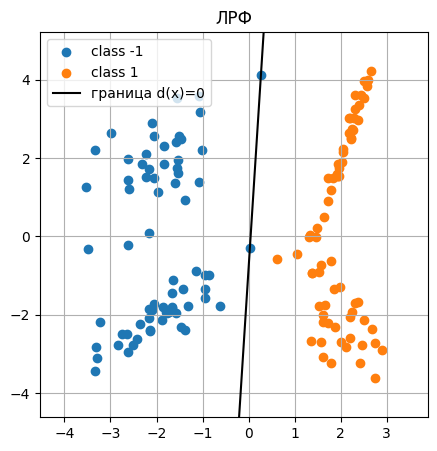

(array([ 2.72073801, -0.14781507, -0.12      ]),
 [-0.0,
  1.7857800221184852,
  1.60496829140351,
  1.4241565606885347,
  1.2433448299735597,
  1.0625330992585846,
  0.8817213685436096,
  0.7009096378286346,
  0.5200979071136596,
  0.3392861763986845,
  0.15847444568370944,
  -0.0])

In [6]:
def F_criterion(w, X_unified):
    """
    Функция критерия: 
    """
    # print(w @ X_unified)
    # print(np.where(w @ X_unified <= 0, w @ X_unified, 0 ))
    # print( - np.sum(np.where(w @ X_unified <= 0, w @ X_unified, 0 )))
    res = w @ X_unified
    return - np.sum(np.where(res <= 0, res, 0 ))
     

def grad_F(w, X_unified):
    """
    Градиент критерия: 
    """
    mul = w @ X_unified
    uklonisti = X_unified.T[np.where(mul<= 0)]
    return -np.sum(uklonisti, axis=0)


def gradient_descent_LDF(X_unified, max_iter=1000, lr=0.01, tol=1e-6):
    """
    Градиентный спуск для минимизации F(w).
    Возвращает w и историю значений критерия на каждой итерации.
    """
    n_features = X_unified.shape[1]
    w = np.zeros(n_features)
    hist = []
    for _ in range(max_iter):
        F_val = F_criterion(w, X_unified.T)
        hist.append(F_val)
        grad = grad_F(w, X_unified.T)
        w_new = w - lr * grad
        # Проверка сходимости по изменению w или по значению F
        if np.linalg.norm(w_new - w) < tol:
            w = w_new
            break
        w = w_new
    return w, hist

def plot_linear(X, y, w, title="ЛРФ"):
    plt.figure(figsize=(5, 5))
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xs = np.linspace(x_min, x_max, 200)
    ys = -(w[0] * xs + w[2]) / w[1]
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}")
    plt.plot(xs, ys, 'k-', label="граница d(x)=0")
    plt.xlim((x_min, x_max))
    plt.ylim((y_min, y_max))
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

w_gd, hist_gd = gradient_descent_LDF(X2_train_unif, max_iter=500, lr=0.01)
plot_linear(X2_train, y2_train, w_gd, title="ЛРФ")
w_gd, hist_gd



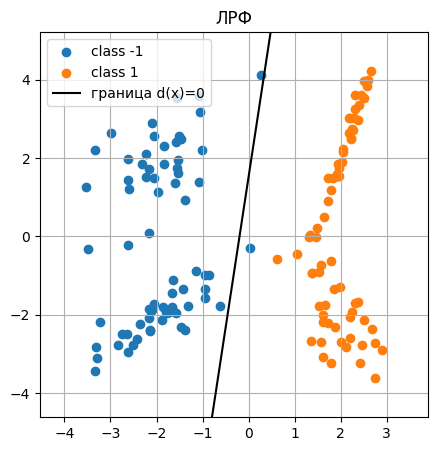

(array([ 0.22107123, -0.02864973,  0.04358459]),
 array([ 0.59162368,  0.46227424,  0.42278126,  0.59355371,  0.72671677,
         0.36248433,  0.24184506,  0.43105778,  0.18179658,  0.42760563,
         0.48329328,  0.45993099,  0.28490972,  0.51888423,  0.60805471,
         0.47052686,  0.36584359,  0.50409464,  0.40087095,  0.43296272,
         0.5032406 ,  0.35381407,  0.6173978 ,  0.47584279,  0.48195641,
         0.21709985,  0.35133717,  0.49416937,  0.27894245,  0.56418325,
         0.01711224,  0.39720229,  0.45935539,  0.47971475,  0.45638523,
        -0.05671541,  0.29853389,  0.41554359,  0.41304457,  0.28862943,
         0.46457442,  0.38183859,  0.40662847,  0.46391653,  0.67268108,
         0.50309622,  0.27107814,  0.59632304,  0.29712675,  0.36833346,
         0.24883604,  0.5309996 ,  0.49119521,  0.59307772,  0.46255527,
         0.71656776,  0.34268427,  0.28989388,  0.34683905,  0.4321851 ,
         0.59439306,  0.60625928,  0.42831743,  0.56569446,  0.41732805,
  

In [7]:
def ho_kashyap(X_unified, max_iter=1000, lr=0.1, tol=1e-3):
    """
    Алгоритм Хо-Кашьяпа для решения X w = b, b > 0.
    Возвращает w и b.
    """
    n_features = X_unified.shape[0]
    # y = np.random.random((1,n_features))
    y = np.random.random(n_features)
    hist = []

    V = X_unified
    V_pseudo = np.linalg.pinv(V)
    w = np.matmul(V_pseudo, y)

    for _ in range(max_iter):
        Vw = np.matmul(V, w)
        if np.all(Vw > 0):
            break
        y = y + lr * (Vw - y)

        # grad = grad_F(w, X_unified.T)
        w_new = np.matmul(V_pseudo, y)
        # Проверка сходимости по изменению w или по значению F
        w = w_new
    return w, y

w_hk, y_hk = ho_kashyap(X2_train_unif, max_iter=1000, lr=0.1)
plot_linear(X2_train, y2_train, w_hk, title="ЛРФ")
w_hk, y_hk

# Лабораторная работа 3
## Обобщённые решающие функции и спрямляющие отображения

**Цель:** реализовать обобщённую решающую функцию через явное нелинейное отображение признаков и показать, как нелинейно неразделимые классы становятся линейно разделимыми в расширенном пространстве.

### Теоретические опорные пункты
- Обобщённая решающая функция $d(x) = \sum w_i f_i(x)$.
- Спрямляющее отображение $\varphi: \mathbb{R}^n \to \mathbb{R}^l$.
- Мономиальные функции как пример набора признаков.

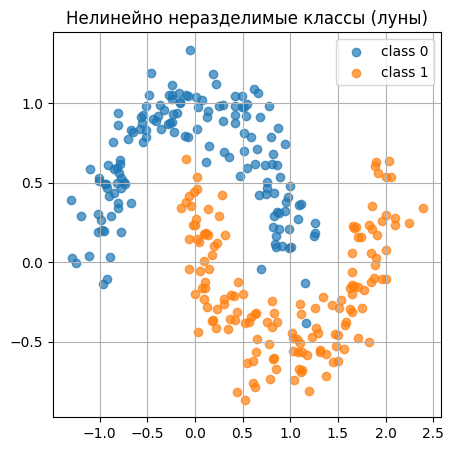

0.8566666666666667

In [8]:
from sklearn.linear_model import LogisticRegression

X_moons, y_moons = generate_nonlinear_moons(n_samples=300, noise=0.15, random_state=0)
plot_dataset(X_moons, y_moons, title="Нелинейно неразделимые классы (луны)")

def fit_linear_classifier(X, y):
    return LogisticRegression(random_state=0).fit(X, y)

clf_linear = fit_linear_classifier(X_moons, y_moons)
acc_linear = accuracy_score(y_moons, clf_linear.predict(X_moons))
acc_linear

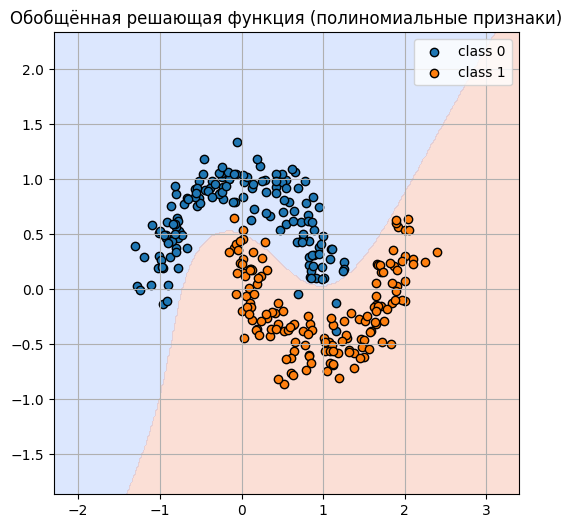

0.98

In [9]:
def plot_decision_boundary_feature_map(X, y, clf, phi, title="ОРФ"):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(
        np.linspace(x_min, x_max, 300),
        np.linspace(y_min, y_max, 300)
    )
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = clf.predict(phi(grid))
    Z = Z.reshape(xx.shape)
    plt.figure(figsize=(6, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, levels=[-0.5, 0.5, 1.5], cmap="coolwarm")
    for cls in np.unique(y):
        plt.scatter(X[y == cls, 0], X[y == cls, 1], label=f"class {cls}", edgecolor="k")
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

def phi_poly2(X):
    x1 = X[:, 0]
    x2 = X[:, 1]
    x12 = np.power(x1, 2)
    x22 = np.power(x2, 2)
    return np.array([np.power(x1, 3), np.power(x2, 3), x12, x22, x1, x2, x1 * x2, x12 * x2, x1 * x22,  np.ones(x1.shape[0])]).T


poly = phi_poly2(X_moons)
clf_phi = fit_linear_classifier(poly, y_moons)

plot_decision_boundary_feature_map(
    X_moons, y_moons, clf_phi, phi_poly2,
    title="Обобщённая решающая функция (полиномиальные признаки)"
)
acc_phi = accuracy_score(y_moons, clf_phi.predict(poly))
acc_phi

# Лабораторная работа 4
## Метрики, расстояния и клетки Вороного

**Цель:** исследовать влияние выбора метрики и стандартизации признаков на классификацию по ближайшему центру и структуру клеток Вороного.

### Теоретические опорные пункты
- Метрики Евклида, Манхэттена, Чебышёва.
- Расстояние от вектора до центра класса и правило классификации по центрам.
- Клетки Вороного.
- Стандартизация признаков (z-score, min–max).

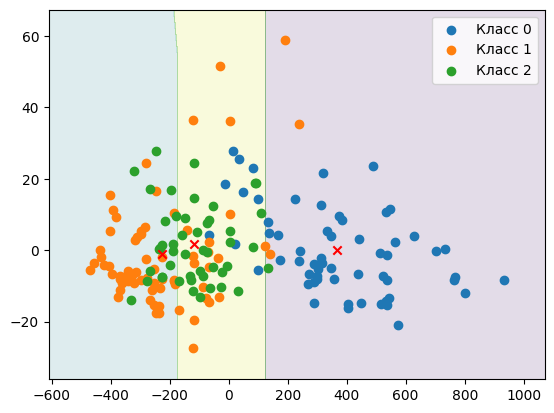

In [26]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler


def euclidean(x, y):
    return np.sqrt(np.sum(np.square(x-y), axis=1))

def manhattan(x, y):
    return (np.sum(np.abs(x-y), axis=1))

def chebyshov(x, y):
    return (np.max(np.abs(x-y), axis=1))

def compute_class_centers(X, y):
    classes = np.unique(y)
    prototypes = []
    for cl in classes:
        X_class = X[y == cl]
        prototypes.append(np.mean(X_class, axis=0)) 
    return np.array(prototypes)

def predict_nearest_center(X, centers, metric="euclidean"):
    if metric == "euclidean":
        func = euclidean
    elif metric == "manhattan":
        func = manhattan
    elif metric == "chebyshov":
        func = chebyshov

    dist_mas = []
    for i in centers:
        dist_mas.append(func(X, [i]* len(X)))
    dist_mas = np.array(dist_mas).T
    return np.argmin(dist_mas, axis=1)

def plot_voronoi_like(X, y, centers, metric="euclidean", title="Клетки Вороного"):
    arg_x, arg_y = (np.max(X[:,0]) - np.min(X[:,0])) / 10, (np.max(X[:,1]) - np.min(X[:,1])) / 10

    min_grid = (np.min(X[:,0])-arg_x, np.min(X[:,1])-arg_y)
    max_grid = (np.max(X[:,0])+arg_x, np.max(X[:,1])+arg_y)
    x_coords = np.arange(min_grid[0], max_grid[0], np.abs(max_grid[0] - min_grid[0])/1000 )
    y_coords = np.arange(min_grid[1], max_grid[1], np.abs(max_grid[1] - min_grid[1])/1000 )
    xv, yv = np.meshgrid(x_coords, y_coords)
    dots = np.c_[xv.ravel(), yv.ravel()]
    res = predict_nearest_center(dots, centers, metric=metric).reshape(xv.shape)

    y_unique = np.unique(y)

    plt.contourf(xv, yv, res, alpha=.15)
    for y_u in y_unique:
        plt.scatter(X[y==y_u, 0], X[y==y_u, 1], label=f"Класс {y_u}")
    plt.legend()
    plt.scatter(centers[:, 0], centers[:, 1], color="red", marker="x")

# Xc, yc = generate_linear_separable()

# X, y = datasets.make_classification(
#     n_samples=200, 
#     n_features=2, 
#     n_informative=2, 
#     n_redundant=0, 
#     n_clusters_per_class=1,
#     n_classes=4,
#     class_sep=1.0, 
#     random_state=156)

from sklearn.datasets import make_classification, make_moons, load_wine
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
def generate_wine(use_pca=False):
    data = load_wine()
    X, y = data.get("data"), data.get("target")
    if use_pca :
        pca = PCA(n_components=2)
        X_pca = pca.fit_transform(X)
        return X_pca, y
    else:
        tsne = TSNE(n_components=2, random_state=42, perplexity=30)
        X_tsne = tsne.fit_transform(X)
        return X_tsne, y

X, y = generate_wine(use_pca=True)
centers_raw = compute_class_centers(X, y)
# plot_voronoi_like(X, y, centers_raw, metric="euclidean", title="Вороной по центрам (raw)")
# plot_voronoi_like(X, y, centers_raw, metric="manhattan", title="Вороной по центрам (raw)")
plot_voronoi_like(X, y, centers_raw, metric="chebyshov", title="Вороной по центрам (raw)")

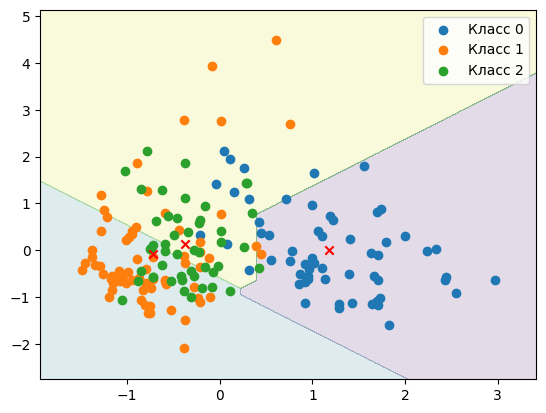

In [33]:
scaler_z = StandardScaler()
X_z = scaler_z.fit_transform(X)
centers_z = compute_class_centers(X_z, y)
# plot_voronoi_like(X_z, y, centers_z, metric="euclidean", title="Вороной по центрам (z-score)")
# plot_voronoi_like(X_z, y, centers_z, metric="manhattan", title="Вороной по центрам (z-score)")
plot_voronoi_like(X_z, y, centers_z, metric="chebyshov", title="Вороной по центрам (z-score)")

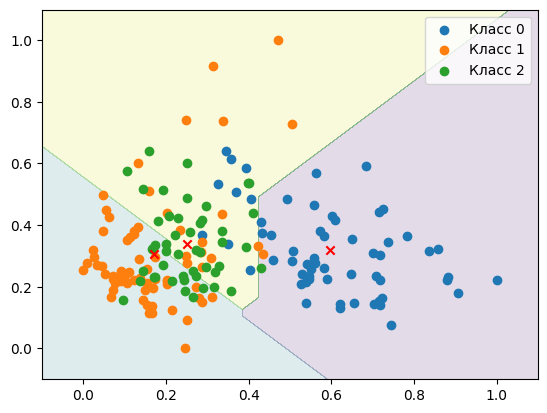

In [32]:
scaler_mm = MinMaxScaler()
X_mm = scaler_mm.fit_transform(X)
centers_z = compute_class_centers(X_mm, y)
# plot_voronoi_like(X_mm, y, centers_z, metric="euclidean", title="Вороной по центрам (z-score)")
# plot_voronoi_like(X_mm, y, centers_z, metric="manhattan", title="Вороной по центрам (z-score)")
plot_voronoi_like(X_mm, y, centers_z, metric="chebyshov", title="Вороной по центрам (z-score)")

Общий вывод: выбор метрики сильно влияет на структуру клеток Вороного. Стандартизация пусть и необходима, но различные её варианты не оказывают сильного влияния.

# Лабораторная работа 5
## Кластеризация и прототипные методы (k-means, maximin) и связь с классификацией

**Цель:** реализовать k-means и один алгоритм расстановки центров (например, maximin), использовать их для прототипного представления классов и связать с методами ближайшего соседа/центра.

### Теоретические опорные пункты
- Математическая постановка задачи кластеризации и критерий внутригруппового разброса.
- Алгоритм k-внутригрупповых средних (k-means).
- Алгоритмы расстановки центров (maximin, простейшая расстановка).
- Прототипы кластеров как опорные точки для классификации.

array([[5.77358491, 2.69245283],
       [6.81276596, 3.07446809],
       [5.006     , 3.428     ]])

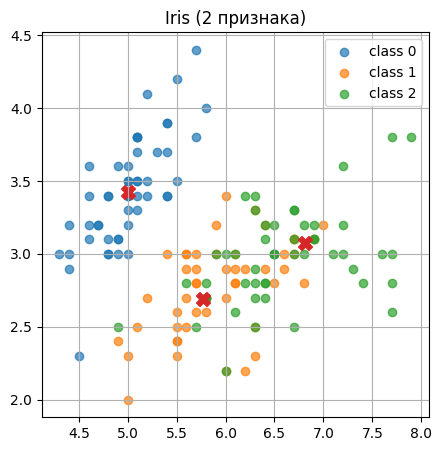

In [98]:
from sklearn.cluster import KMeans

iris = datasets.load_iris()
X_iris = iris.data[:, 0:2]
y_iris = iris.target

plot_dataset(X_iris, y_iris, title="Iris (2 признака)")

def run_kmeans(X, n_clusters, random_state=0):
    km = KMeans(n_clusters=n_clusters, random_state=random_state, n_init=10)
    labels = km.fit_predict(X)
    centers = km.cluster_centers_
    return km, labels, centers

km_iris, labels_iris, centers_iris = run_kmeans(X_iris, n_clusters=3)
plt.scatter(centers_iris[:,0], centers_iris[:,1], marker="X", s=100)
centers_iris

In [76]:
import numpy as np

def maximin_centers(X, dist_metric="euclidean", max_centers=5):
    X = np.asarray(X)
    
    N = X.shape[0]

    q = True
    centers_idx = [0]    

    while len(centers_idx) < max_centers:
        
        dists = []
        for i in range(N):
            if i in centers_idx:
                dists.append(0.0)
                continue
            x = X[i]
            d_min = np.inf
            for idx in centers_idx:
                c = X[idx]
                if dist_metric == "euclidean":
                    d = np.linalg.norm(x - c)
                else:
                    # здесь можно добавить другие метрики,
                    
                    d = np.linalg.norm(x - c)
                if d < d_min:
                    d_min = d
            dists.append(d_min)
 
        farthest_idx = np.argmax(dists)
        if dists[farthest_idx] == 0:
            break
        centers_idx.append(farthest_idx)
        if len(centers_idx) == 2 and q:
            q = False
            centers_idx.pop(0)

    centers = X[centers_idx]
    return centers_idx, centers


idx_mm, centers_mm = maximin_centers(X_iris, max_centers=3)
idx_mm, centers_mm

([118, 22, 80],
 array([[2.6, 6.9],
        [3.6, 1. ],
        [2.4, 3.8]]))

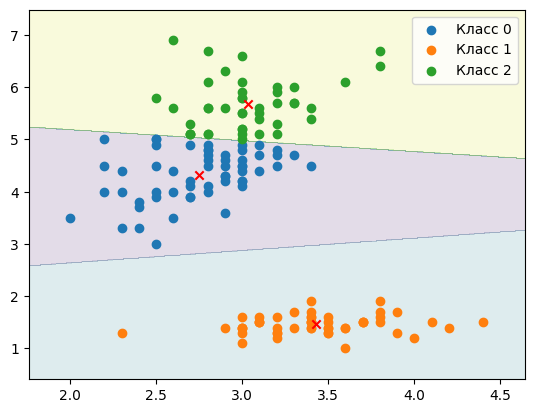

In [74]:
def plot_clusters_with_centers(X, labels, centers, title="Clusters"):
    plt.figure(figsize=(6, 6))
    for lab in np.unique(labels):
        plt.scatter(X[labels == lab, 0], X[labels == lab, 1], label=f"cluster {lab}")
    plt.scatter(centers[:, 0], centers[:, 1], c="black", marker="X", s=150, label="centers")
    plt.legend()
    plt.title(title)
    plt.grid(True)
    plt.show()

# plot_clusters_with_centers(X_iris, labels_iris, centers_iris, title="k-means, k=3")
plot_voronoi_like(X_iris, labels_iris, centers_iris, metric="euclidean", title="Вороной по центрам (z-score)")

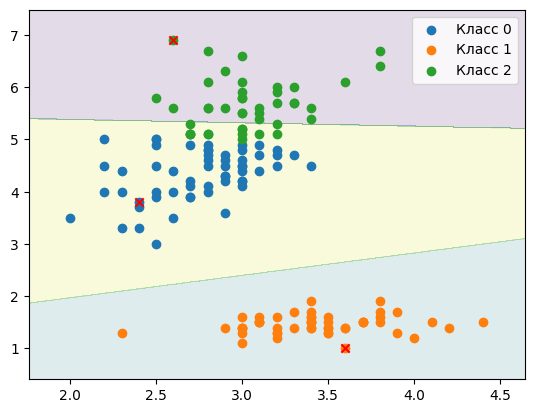

In [77]:
# idx_mm, centers_mm
# plot_clusters_with_centers(X_iris, labels_iris, centers_mm, title="k-means, k=3")
plot_voronoi_like(X_iris, labels_iris, centers_mm, metric="euclidean", title="Вороной по центрам (z-score)")

array([[6.81276596, 3.07446809],
       [5.77358491, 2.69245283],
       [5.006     , 3.428     ]])

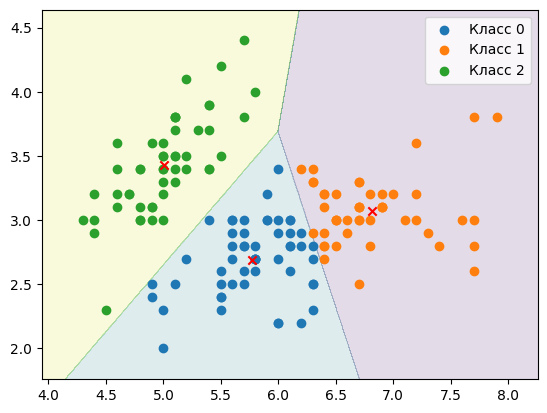

In [101]:
import numpy as np

def k_central_means(X, dist_metric="euclidean", count_centers=5):
    X = np.asarray(X)
    
    N = X.shape[0]

    centers = [[None, None]]*count_centers
    new_centers = X[:count_centers].copy()

    while np.any(new_centers != centers) :
        centers = new_centers.copy()

        y_dict = {i:[] for i in range(count_centers)}
        
        for i, dot in enumerate(X):
            dmin = np.inf
            c_indx = None
            for j, center in enumerate(centers):
                d = np.linalg.norm(dot - center)
                if d < dmin:
                    dmin = d
                    c_indx = j
            y_dict[c_indx].append(i)
     
        # centers = new_centers.copy()   
        for key, values in y_dict.items():
            new_centers[key] = np.mean(X[values, :], axis=0)
    
    return new_centers
        
centers_kn = k_central_means(X_iris, count_centers=3)
plot_voronoi_like(X_iris, labels_iris, centers_kn, metric="euclidean", title="Вороной по центрам (z-score)")
centers_kn

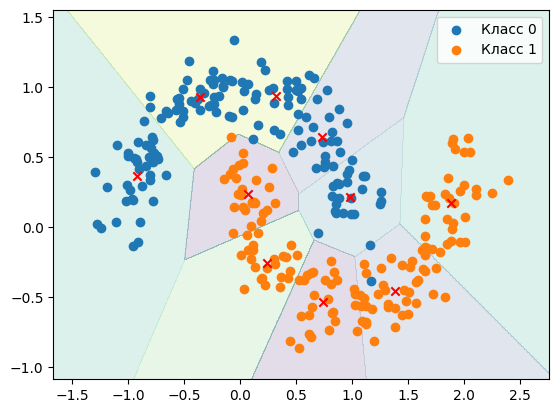

In [103]:
X_moons, y_moons = generate_nonlinear_moons(n_samples=300, noise=0.15, random_state=0)

centers_kn_moons = k_central_means(X_moons, count_centers=10)
plot_voronoi_like(X_moons, y_moons, centers_kn_moons, metric="euclidean", title="Вороной по центрам (z-score)")